# **Breast Cancer Classification Using Support Vector Machine (SVM)**

## Project Overview

In this project, we use the **Support Vector Machine (SVM)** algorithm to predict whether a breast tumor is **malignant or benign** based on diagnostic features. The goal is to build an effective binary classification model and understand how SVM uses decision boundaries and kernels for classification.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Data 

In [2]:
df = pd.read_csv("data.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

In [6]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,   # Malignant
    "B": 0    # Benign
})

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Dataset Description

The dataset used in this project is the **Breast Cancer Wisconsin (Diagnostic) Dataset**. It contains measurements of cell nuclei extracted from breast tissue samples. The objective is to classify tumors as **Malignant (1)** or **Benign (0)** using machine learning techniques.

The dataset contains **569 observations** with **30 numerical features** and one target variable (`diagnosis`).

| Column Category | Description |
|---|---|
| Number of Samples | 569 breast tissue samples |
| Number of Features | 30 numerical input features |
| Target Variable | `diagnosis` |
| Classification Type | Binary Classification |
| Target Classes | 0 = Benign, 1 = Malignant |
| Feature Type | Numerical (float values) |
| Missing Values | No missing values present |
| Machine Learning Task | Predict whether a tumor is malignant or benign |

### Feature Description

| Feature Group | Description |
|---|---|
| `radius` | Mean distance from the center to points on the perimeter of the cell nucleus |
| `texture` | Variation in gray-scale intensity values of the nucleus |
| `perimeter` | Perimeter of the cell nucleus |
| `area` | Area of the cell nucleus |
| `smoothness` | Local variation in radius lengths |
| `compactness` | Measures how compact the nucleus shape is |
| `concavity` | Severity of concave portions of the nucleus |
| `concave points` | Number of concave portions in the nucleus boundary |
| `symmetry` | Symmetry of the nucleus |
| `fractal dimension` | Complexity of the nucleus boundary |

Each measurement is provided in three forms:

| Feature Type | Description |
|---|---|
| `_mean` | Average value of the measurement |
| `_se` | Standard error of the measurement |
| `_worst` | Largest or most extreme value of the measurement |

These features are used by the **Support Vector Classifier (SVC)** to learn the decision boundary that separates malignant and benign tumors.

| Term | Meaning | Description |
|---|---|---|
| **Benign** | Non-cancerous | A tumor that does not invade nearby tissues or spread to other parts of the body. It is generally less dangerous and often does not become life-threatening. |
| **Malignant** | Cancerous | A tumor that contains cancer cells and can invade surrounding tissues or spread to other parts of the body (**metastasis**). |

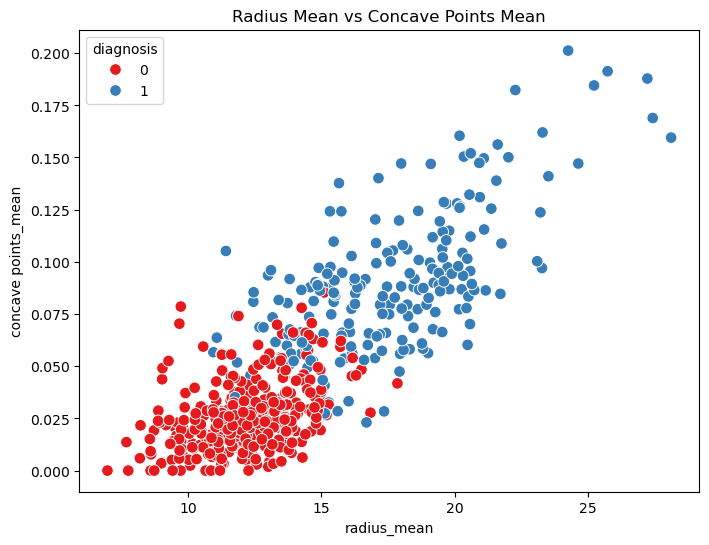

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="radius_mean",
    y="concave points_mean",
    hue="diagnosis",
    palette="Set1",
    s=70
)

plt.title("Radius Mean vs Concave Points Mean")
plt.show()

# Target Distribution

In [10]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

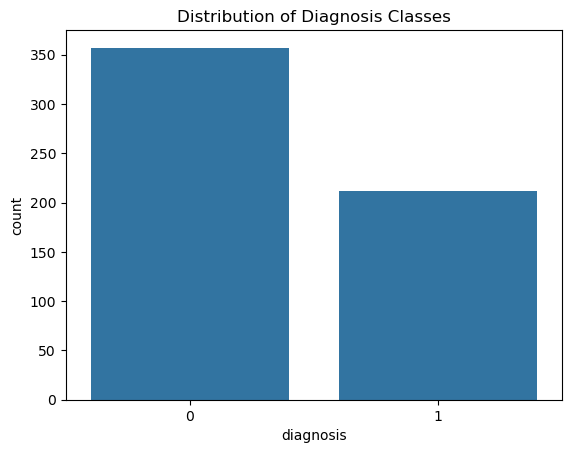

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="diagnosis"
)

plt.title("Distribution of Diagnosis Classes")
plt.show()

## Separate Features and Target

In [12]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

# Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Train Baseline Linear SVM Model

In [15]:
from sklearn.svm import SVC


svm_linear = SVC(
    kernel="linear",
    random_state=42
)


svm_linear.fit(
    X_train_scaled,
    y_train
)

SVC(kernel='linear', random_state=42)

# Make Predictions

In [16]:
y_pred = svm_linear.predict(X_test_scaled)

# Evaluate Model

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print(
    accuracy_score(
        y_test,
        y_pred
    )
)


print(
    classification_report(
        y_test,
        y_pred
    )
)

0.9649122807017544
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



# Visualize decision boundary using two features radius_mean and concave points_mean

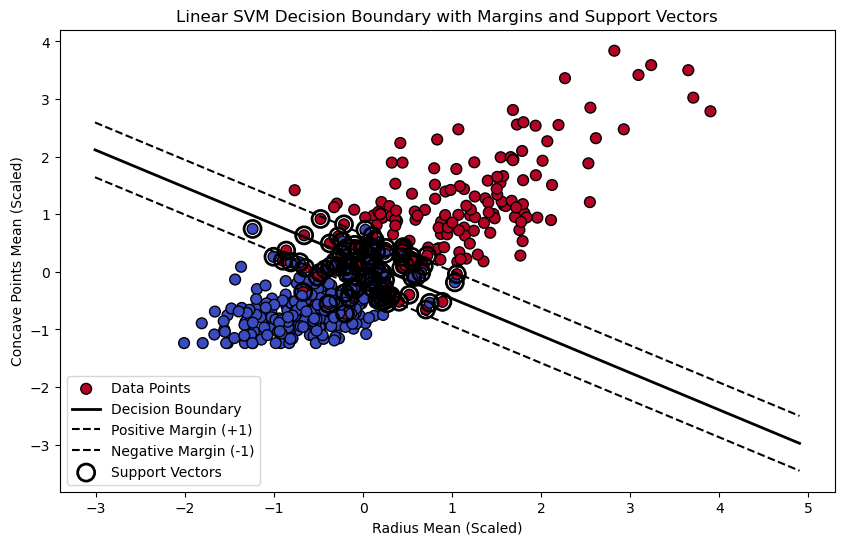

In [23]:
# Select two features for visualization
X_vis = df[["radius_mean", "concave points_mean"]]

y_vis = df["diagnosis"]


# Train-test split
from sklearn.model_selection import train_test_split

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_vis,
    test_size=0.2,
    random_state=42,
    stratify=y_vis
)


# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler_vis = StandardScaler()

X_train_vis_scaled = scaler_vis.fit_transform(X_train_vis)

X_test_vis_scaled = scaler_vis.transform(X_test_vis)


# Train Linear SVM
from sklearn.svm import SVC

svm_vis = SVC(
    kernel="linear",
    C=1
)

svm_vis.fit(
    X_train_vis_scaled,
    y_train_vis
)


# Get coefficients and intercept
import numpy as np
import matplotlib.pyplot as plt

w = svm_vis.coef_[0]
b = svm_vis.intercept_[0]


# Create values for decision boundary
x_min = X_train_vis_scaled[:, 0].min() - 1
x_max = X_train_vis_scaled[:, 0].max() + 1


x1 = np.linspace(
    x_min,
    x_max,
    100
)


# Decision boundary:
# w0*x1 + w1*x2 + b = 0

x2 = -(w[0] * x1 + b) / w[1]


# Calculate margin distance

margin = 1 / np.sqrt(np.sum(w ** 2))


# Plot
plt.figure(figsize=(10, 6))


# Scatter plot of classes

plt.scatter(
    X_train_vis_scaled[:, 0],
    X_train_vis_scaled[:, 1],
    c=y_train_vis,
    cmap="coolwarm",
    s=60,
    edgecolors="k",
    label="Data Points"
)


# Decision boundary

plt.plot(
    x1,
    x2,
    "k-",
    linewidth=2,
    label="Decision Boundary"
)


# Positive margin

plt.plot(
    x1,
    x2 + margin,
    "k--",
    linewidth=1.5,
    label="Positive Margin (+1)"
)


# Negative margin

plt.plot(
    x1,
    x2 - margin,
    "k--",
    linewidth=1.5,
    label="Negative Margin (-1)"
)


# Highlight support vectors

support_vectors = svm_vis.support_vectors_

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)


# Labels and title

plt.xlabel("Radius Mean (Scaled)")
plt.ylabel("Concave Points Mean (Scaled)")

plt.title(
    "Linear SVM Decision Boundary with Margins and Support Vectors"
)

plt.legend()

plt.show()

# Train SVM with Different Kernels

# Linear Kernel

In [24]:
svm_linear = SVC(
    kernel="linear",
    C=1
)

svm_linear.fit(
    X_train_scaled,
    y_train
)

SVC(C=1, kernel='linear')

# Polynomial Kernel

In [25]:
svm_poly = SVC(
    kernel="poly",
    degree=3,
    C=1
)

svm_poly.fit(
    X_train_scaled,
    y_train
)

SVC(C=1, kernel='poly')

# RBF Kernel

In [40]:
svm_rbf = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_rbf.fit(
    X_train_scaled,
    y_train
)

SVC(C=1)

# Sigmoid Kernel

In [41]:
svm_sigmoid = SVC(
    kernel="sigmoid",
    C=1
)

svm_sigmoid.fit(
    X_train_scaled,
    y_train
)

SVC(C=1, kernel='sigmoid')

# Make Predictions

In [42]:
y_pred_linear = svm_linear.predict(X_test_scaled)

y_pred_poly = svm_poly.predict(X_test_scaled)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

y_pred_sigmoid = svm_sigmoid.predict(X_test_scaled)

In [43]:
import pandas as pd

results = pd.DataFrame(
    {
        "Model": [
            "Linear SVM",
            "Polynomial SVM",
            "RBF SVM",
            "Sigmoid SVM"
        ],
        
        "Accuracy": [
            accuracy_score(y_test, y_pred_linear),
            accuracy_score(y_test, y_pred_poly),
            accuracy_score(y_test, y_pred_rbf),
            accuracy_score(y_test, y_pred_sigmoid)
        ]
    }
)


results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,RBF SVM,0.973684
0,Linear SVM,0.964912
3,Sigmoid SVM,0.947368
1,Polynomial SVM,0.885965


# Hyperparameter Tuning using GridSearchCV

## Import GridSearchCV

In [31]:
from sklearn.model_selection import GridSearchCV

## Define SVM Model

In [32]:
from sklearn.svm import SVC

svm_model = SVC()

## Define Parameter Grid

| Hyperparameter | Purpose |
|---|---|
| `kernel` | Defines the type of decision boundary used by SVM. Common options include Linear, Polynomial, RBF (Radial Basis Function), and Sigmoid. |
| `C` | Controls the penalty for misclassified points. A smaller C creates a wider margin with more tolerance for errors, while a larger C tries to classify training samples correctly with a narrower margin. |
| `gamma` | Controls the influence of individual data points. It determines how far the effect of a single training example reaches, mainly used with RBF, Polynomial, and Sigmoid kernels. |
| `degree` | Defines the degree of the polynomial function. It is only applicable when using the Polynomial (`poly`) kernel. |

In [33]:
param_grid = {

    "kernel": [
        "linear",
        "poly",
        "rbf",
        "sigmoid"
    ],

    "C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "gamma": [
        "scale",
        "auto"
    ],

    "degree": [
        2,
        3,
        4
    ]
}

## Create GridSearchCV Object

In [37]:
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

## Train GridSearchCV

In [38]:
grid_search.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'degree': [2, 3, 4],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy')

## Find Best Parameters

In [36]:
grid_search.best_params_

{'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}

In [39]:
grid_search.best_score_

0.9758241758241759

## Best Model Selection using GridSearchCV

GridSearchCV evaluated multiple combinations of SVM hyperparameters, including different kernels, values of C, gamma settings, and polynomial degrees. The best-performing model was selected based on the highest cross-validation accuracy.

The optimal hyperparameter combination obtained was:

| Hyperparameter | Best Value |
|---|---|
| Kernel | RBF (Radial Basis Function) |
| C | 1 |
| Gamma | Scale |
| Degree | 2 |

The selected RBF-based Support Vector Classifier achieved a cross-validation accuracy of **97.58%**.

This indicates that the model was able to effectively learn the relationship between cell nucleus characteristics and the diagnosis class. The RBF kernel performed better than the other kernels because it can capture non-linear patterns in the data while maintaining good generalization.